# A1 — Vision Transformers: classificação de lesões de pele (HAM10000)

**Execução:** Google Colab com GPU T4.

| | Valor |
|---|---|
| Tempo estimado de execução | [preencher com o TOTAL da célula "Resumo de tempo e memória"] |
| Pico de memória da GPU (VRAM) | [preencher] |
| Pico de RAM do processo | [preencher] |

> Valores medidos na execução de referência (runtime limpo, modo Drive). O detalhamento por
> etapa fica em `report_assets/tempos_execucao.csv`.

In [1]:
import time
_T_INICIO_NOTEBOOK = time.perf_counter()  # tempo total do notebook (R8)
TEMPOS = []  # registro das etapas cronometradas (ver src/utils.cronometrar)

REPO_URL = "https://github.com/anacaetano02/Deep-Learning-Visao-Computacional.git"
SUBPASTA = "A1_vision_transformers"
REPO_DIR = "/content/repo"

if not REPO_URL:
    raise ValueError("Defina REPO_URL com a URL do seu repositório git antes de continuar.")

import os
import subprocess

PROJECT_DIR = os.path.join(REPO_DIR, SUBPASTA)

if not os.path.isdir(os.path.join(REPO_DIR, ".git")):
    # --filter=blob:none: baixa só os metadados de commit/árvore, os
    # arquivos (blobs) de fora do sparse-checkout nunca são transferidos.
    # --sparse liga o modo cone do sparse-checkout (mais rápido e mais
    # simples de configurar que listar padrões manualmente).
    subprocess.run(
        ["git", "clone", "--filter=blob:none", "--sparse", "--depth", "1", REPO_URL, REPO_DIR],
        check=True,
    )
    subprocess.run(["git", "sparse-checkout", "set", SUBPASTA], cwd=REPO_DIR, check=True)
else:
    # Repositório já clonado nesta sessão do Colab (variável de estado que
    # sobrevive a reexecuções de célula, só não a reinício de runtime) —
    # git pull traz commits novos em vez de simplesmente pular, para
    # mudanças feitas no código depois do clone inicial não ficarem presas
    # do lado de fora.
    print(f"Repositório já clonado em '{REPO_DIR}' — buscando mudanças mais recentes...")
    subprocess.run(["git", "pull"], cwd=REPO_DIR, check=True)

TEMPOS.append({"etapa": "clone/pull do repositório", "segundos": round(time.perf_counter() - _T_INICIO_NOTEBOOK, 1),
               "pico_vram_gb": None, "pico_ram_processo_gb": None})

In [2]:
import importlib, sys

# Recarrega os módulos do projeto já importados (depois do git pull)
for nome in sorted(m for m in sys.modules if m == "src" or m.startswith("src.")):
    importlib.reload(sys.modules[nome])


In [3]:
# Onde salvar dados e artefatos desta execução.
from pathlib import Path

SALVAR_NO_DRIVE = True  # AJUSTE conforme sua preferência.

if SALVAR_NO_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    # AJUSTE: caminho da pasta de saída dentro do seu Drive.
    BASE_DIR = Path("/content/drive/MyDrive/deep_learning_visao_computacional/A1_vision_transformers")
else:
    BASE_DIR = Path("/content/A1_vision_transformers_saida")

print(f"BASE_DIR = {BASE_DIR} (Drive: {SALVAR_NO_DRIVE})")

Mounted at /content/drive
BASE_DIR = /content/drive/MyDrive/deep_learning_visao_computacional/A1_vision_transformers (Drive: True)


In [4]:
# Estrutura de saída (Drive/BASE_DIR). Tudo como Path, para usar o operador "/".
DIR_DADOS_RAW = BASE_DIR / "data" / "raw"
DIR_DADOS_PROCESSADOS = BASE_DIR / "data" / "processed"
DIR_OUTPUTS = BASE_DIR / "outputs"
DIR_CHECKPOINTS = DIR_OUTPUTS / "checkpoints"
DIR_REPORT_ASSETS = DIR_OUTPUTS / "report_assets"
DIR_RUNS = BASE_DIR / "runs"  # logs do TensorBoard

LOCAL_DIR = Path("/content/local_data")  # cópia local, nunca no Drive

for d in (DIR_DADOS_RAW, DIR_DADOS_PROCESSADOS, DIR_CHECKPOINTS, DIR_REPORT_ASSETS, DIR_RUNS, LOCAL_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("Diretórios prontos:")
for d in (DIR_DADOS_RAW, DIR_DADOS_PROCESSADOS, DIR_CHECKPOINTS, DIR_REPORT_ASSETS, DIR_RUNS, LOCAL_DIR):
    print(f"  {d}")

Diretórios prontos:
  /content/drive/MyDrive/deep_learning_visao_computacional/A1_vision_transformers/data/raw
  /content/drive/MyDrive/deep_learning_visao_computacional/A1_vision_transformers/data/processed
  /content/drive/MyDrive/deep_learning_visao_computacional/A1_vision_transformers/outputs/checkpoints
  /content/drive/MyDrive/deep_learning_visao_computacional/A1_vision_transformers/outputs/report_assets
  /content/drive/MyDrive/deep_learning_visao_computacional/A1_vision_transformers/runs
  /content/local_data


In [5]:
import sys
import polars as pl
import torch
from transformers import AutoImageProcessor

if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

from src.data import (
    extrair_metadados,
    deduplicar_por_imagem,
    montar_split_por_lesao,
    validar_split,
    salvar_split,
    carregar_split,
    COLUNA_GRUPO,
    COLUNAS_SPLIT,
    montar_transforms,
    preparar_dataloaders,
    ORDEM_SPLITS,
    INDICE_PARA_CLASSE,
)

from src.eda import (
    tabela_vazamento,
    tabela_contagens,
    tabela_classes_por_split,
    figura_batch,
)

from src.utils import cronometrar, tabela_tempos

print("Módulos do projeto importados com sucesso.")

Módulos do projeto importados com sucesso.


In [6]:
SEED = 42
PROPORCOES_SPLIT = {"test": 0.15, "validation": 0.15, "train": 0.70}

# Modelos (decisões registradas no REQUISITOS.md)
CHECKPOINT_PRE = "google/vit-base-patch16-224"
TAMANHO_ZERO, PATCH_ZERO = 128, 16
BATCH_SIZE = {"pre": 32, "zero": 64}  # a ajustar na Fase 4 conforme a memória da T4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("AVISO: sem GPU. No Colab, use Ambiente de execução > Alterar o tipo > GPU T4.")

from datetime import datetime
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
print(f"RUN_ID = {RUN_ID}")

GPU: Tesla T4
RUN_ID = 20260927_213900


In [7]:
from datasets import load_dataset

# Versão do dataset fixada pelo hash do commit no Hub (último commit: 25/01/2023).
# O split e o idx_original do CSV dependem da ordem das linhas desta versão.
# Para conferir o hash atual: HfApi().dataset_info("marmal88/skin_cancer").sha
NOME_DATASET = "marmal88/skin_cancer"
REVISAO_DATASET = "bdd59e10860746202dfdc452e0ac3a9eaa25268d"

with cronometrar("download/carregamento do dataset (HF)", TEMPOS):
    dataset = load_dataset(NOME_DATASET, revision=REVISAO_DATASET)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


README.md:   0%|          | 0.00/3.24k [00:00<?, ?B/s]

data/train-00000-of-00005-7eed077f2f8e6d(…): reconstructing file:   0%|          |  0.00B /  521MB            

data/train-00000-of-00005-7eed077f2f8e6d(…): downloading bytes:           |  0.00B            

data/train-00001-of-00005-50ba64fd20294b(…): reconstructing file:   0%|          |  0.00B /  525MB            

...

data/test-00000-of-00001-61e7cf54bf274ae(…): reconstructing file:   0%|          |  0.00B /  355MB            

data/test-00000-of-00001-61e7cf54bf274ae(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/9577 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2492 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1285 [00:00<?, ? examples/s]

## Dados: deduplicação e novo split por lesão

> **A escrever (R1, R10):** por que o split do Hugging Face foi descartado e o que foi feito no lugar.
> Use os números das tabelas abaixo (`contagens`, `vazamento_antes_*`, `vazamento_depois_*`, `dx_por_split_*`)
> e responda: quanto do teste/validação já estava no treino? Por que o vazamento por `lesion_id` importa
> além do por `image_id`? Como o novo split evita isso, e qual a limitação para as classes raras?

In [8]:
with cronometrar("metadados, deduplicação, split e tabelas", TEMPOS):
    # Etapas: bruto -> deduplicado -> com split
    df_bruto = extrair_metadados(dataset)
    df_dedup = deduplicar_por_imagem(df_bruto)
    df_split = montar_split_por_lesao(df_dedup, PROPORCOES_SPLIT, seed=SEED)
    validar_split(df_split)

    execucoes = {
        "vazamento_antes_image_id":   (df_bruto, "split_original", "image_id"),
        "vazamento_antes_lesion_id":  (df_bruto, "split_original", COLUNA_GRUPO),
        "vazamento_depois_image_id":  (df_split, "split", "image_id"),
        "vazamento_depois_lesion_id": (df_split, "split", COLUNA_GRUPO),
    }
    tabelas = {
        nome: tabela_vazamento(df, coluna, coluna_split)
        for nome, (df, coluna_split, coluna) in execucoes.items()
    }
    tabelas["contagens"] = tabela_contagens(df_bruto, df_dedup)
    tabelas["dx_por_split_antes"] = tabela_classes_por_split(df_bruto, "split_original")
    tabelas["dx_por_split_depois"] = tabela_classes_por_split(df_split)

    # 1) Testes de sanidade ANTES de gravar: se falharem, nenhum CSV errado vai para outputs/
    contagens = dict(zip(tabelas["contagens"]["metrica"], tabelas["contagens"]["valor"]))
    assert contagens["linhas_bruto"] == 13_354, f"Bruto com {contagens['linhas_bruto']} linhas"
    assert contagens["duplicatas_removidas"] == 3_339, f"{contagens['duplicatas_removidas']} duplicatas removidas"
    assert contagens[f"{COLUNA_GRUPO}_unicos_deduplicado"] == contagens[f"{COLUNA_GRUPO}_unicos"], (
        "A deduplicação perdeu lesões"
    )

    # O "antes" tem de bater exatamente com o que já foi medido (linhas de B afetadas,
    # pares train_vs_validation, train_vs_test, validation_vs_test); o "depois" tem de ser zero
    esperado = {"vazamento_antes_image_id": [2105, 1025, 209], "vazamento_antes_lesion_id": [2272, 1132, 386]}
    for nome, linhas in esperado.items():
        obtido = tabelas[nome]["linhas_de_B_afetadas"].to_list()
        assert obtido == linhas, f"{nome}: esperava {linhas}, obtive {obtido}. Algo mudou na extração."
    for nome in ("vazamento_depois_image_id", "vazamento_depois_lesion_id"):
        assert tabelas[nome]["linhas_de_B_afetadas"].sum() == 0, f"{nome} deveria ser zero"

    # 2) Só então exibe (sem cortar colunas) e grava nos artefatos do relatório
    with pl.Config(tbl_cols=-1, tbl_width_chars=250):
        for nome, tabela in tabelas.items():
            print(nome)
            display(tabela)
            tabela.write_csv(DIR_REPORT_ASSETS / f"{nome}.csv")

Split OK: zero vazamento de image_id, lesion_id entre os pares de splits.
vazamento_antes_image_id


par,grupos_em_comum,linhas_de_B_afetadas,pct_linhas_de_B
str,i64,i64,f64
"""train_vs_validation""",2105,2105,84.47
"""train_vs_test""",1025,1025,79.77
"""validation_vs_test""",209,209,16.26


vazamento_antes_lesion_id


par,grupos_em_comum,linhas_de_B_afetadas,pct_linhas_de_B
str,i64,i64,f64
"""train_vs_validation""",2113,2272,91.17
"""train_vs_test""",1069,1132,88.09
"""validation_vs_test""",360,386,30.04


vazamento_depois_image_id


...

metrica,valor
str,i64
"""linhas_bruto""",13354
"""image_id_unicos""",10015
"""lesion_id_unicos""",7470
"""linhas_deduplicado""",10015
"""duplicatas_removidas""",3339
"""lesion_id_unicos_deduplicado""",7470


dx_por_split_antes


dx,n_imagens_train,n_imagens_validation,n_imagens_test,n_lesoes_train,n_lesoes_validation,n_lesoes_test,pct_n_imagens_train,pct_n_imagens_validation,pct_n_imagens_test,pct_n_lesoes_train,pct_n_lesoes_validation,pct_n_lesoes_test
str,u32,u32,u32,u32,u32,u32,f64,f64,f64,f64,f64,f64
"""actinic_keratoses""",315,82,42,223,74,42,3.29,3.29,3.27,3.09,3.18,3.44
"""basal_cell_carcinoma""",487,124,67,317,115,63,5.09,4.98,5.21,4.39,4.94,5.16
"""benign_keratosis-like_lesions""",1048,275,142,703,256,131,10.94,11.04,11.05,9.73,10.99,10.73
"""dermatofibroma""",110,30,14,72,27,14,1.15,1.2,1.09,1.0,1.16,1.15
"""melanocytic_Nevi""",6405,1666,858,5207,1579,825,66.88,66.85,66.77,72.06,67.8,67.57
"""melanoma""",1076,280,144,608,245,130,11.24,11.24,11.21,8.41,10.52,10.65
"""vascular_lesions""",136,35,18,96,33,16,1.42,1.4,1.4,1.33,1.42,1.31


dx_por_split_depois


dx,n_imagens_train,n_imagens_validation,n_imagens_test,n_lesoes_train,n_lesoes_validation,n_lesoes_test,pct_n_imagens_train,pct_n_imagens_validation,pct_n_imagens_test,pct_n_lesoes_train,pct_n_lesoes_validation,pct_n_lesoes_test
str,u32,u32,u32,u32,u32,u32,f64,f64,f64,f64,f64,f64
"""actinic_keratoses""",232,47,48,160,34,34,3.31,3.16,3.14,3.06,3.04,3.04
"""basal_cell_carcinoma""",365,79,70,229,49,49,5.22,5.31,4.58,4.38,4.38,4.38
"""benign_keratosis-like_lesions""",769,162,168,509,109,109,10.99,10.88,11.0,9.73,9.73,9.73
"""dermatofibroma""",82,18,15,51,11,11,1.17,1.21,0.98,0.98,0.98,0.98
"""melanocytic_Nevi""",4667,997,1041,3783,810,810,66.68,66.96,68.17,72.33,72.32,72.32
"""melanoma""",783,167,163,430,92,92,11.19,11.22,10.67,8.22,8.21,8.21
"""vascular_lesions""",101,19,22,68,15,15,1.44,1.28,1.44,1.3,1.34,1.34


In [9]:
with cronometrar("conferência do split versionado", TEMPOS):
    # Split versionado (dentro do repo, só leitura) x split gerado (fora do repo).
    # Gerar dentro do clone quebraria o próximo git pull quando o arquivo for commitado.
    SPLIT_VERSIONADO = Path(PROJECT_DIR) / "split_lesoes.csv"
    SPLIT_GERADO = DIR_DADOS_PROCESSADOS / "split_lesoes.csv"

    if SPLIT_VERSIONADO.exists():
        df_split_salvo = carregar_split(SPLIT_VERSIONADO)
        validar_split(df_split_salvo)
        # O split recalculado acima tem de ser idêntico ao versionado
        recalculado = df_split.select(COLUNAS_SPLIT).sort("image_id")
        assert df_split_salvo.sort("image_id").equals(recalculado), (
            "O split recalculado difere do versionado: o dataset ou o código do split mudou"
        )
        print("Split versionado confere com o recalculado.")
    else:
        salvar_split(df_split, SPLIT_GERADO)
        print(f"Copie {SPLIT_GERADO} para A1_vision_transformers/split_lesoes.csv no repositório e faça commit.")

    SPLIT_OFICIAL = df_split_salvo if SPLIT_VERSIONADO.exists() else df_split
    print(f"Split oficial: {SPLIT_OFICIAL.height} imagens")

Split carregado de /content/repo/A1_vision_transformers/split_lesoes.csv (10015 linhas)
Split OK: zero vazamento de image_id, lesion_id entre os pares de splits.
Split versionado confere com o recalculado.
Split oficial: 10015 imagens


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

pre   train      (32, 3, 224, 224) torch.float32 [-1.00, 1.00] rótulos [0, 1, 2, 3, 4, 5, 6]


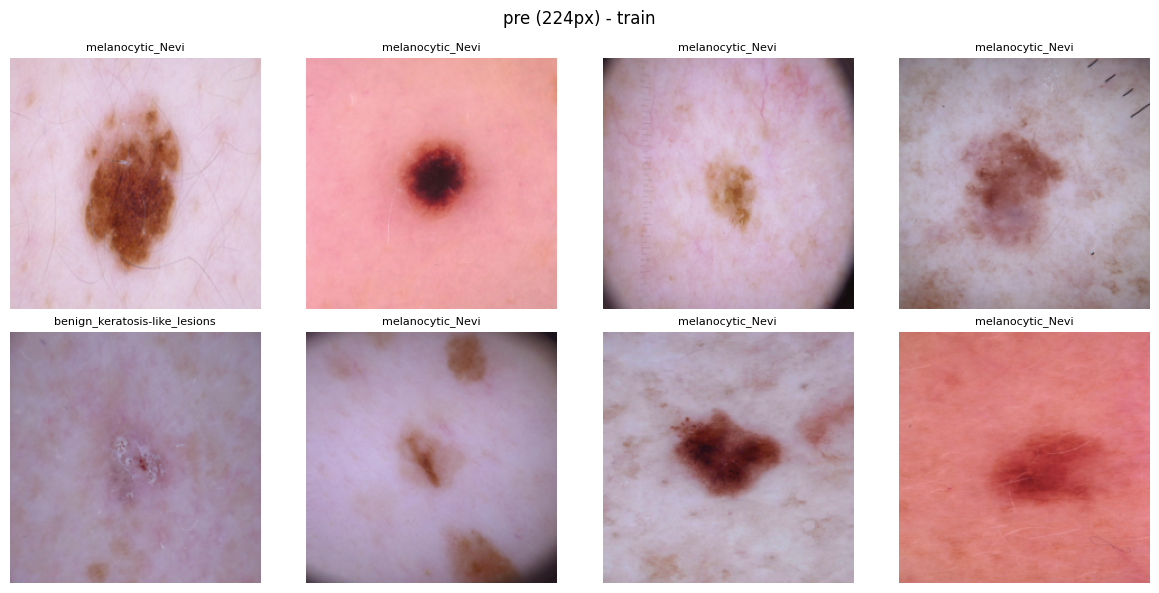

pre   validation (32, 3, 224, 224) torch.float32 [-1.00, 1.00] rótulos [0, 1, 2, 4, 6]


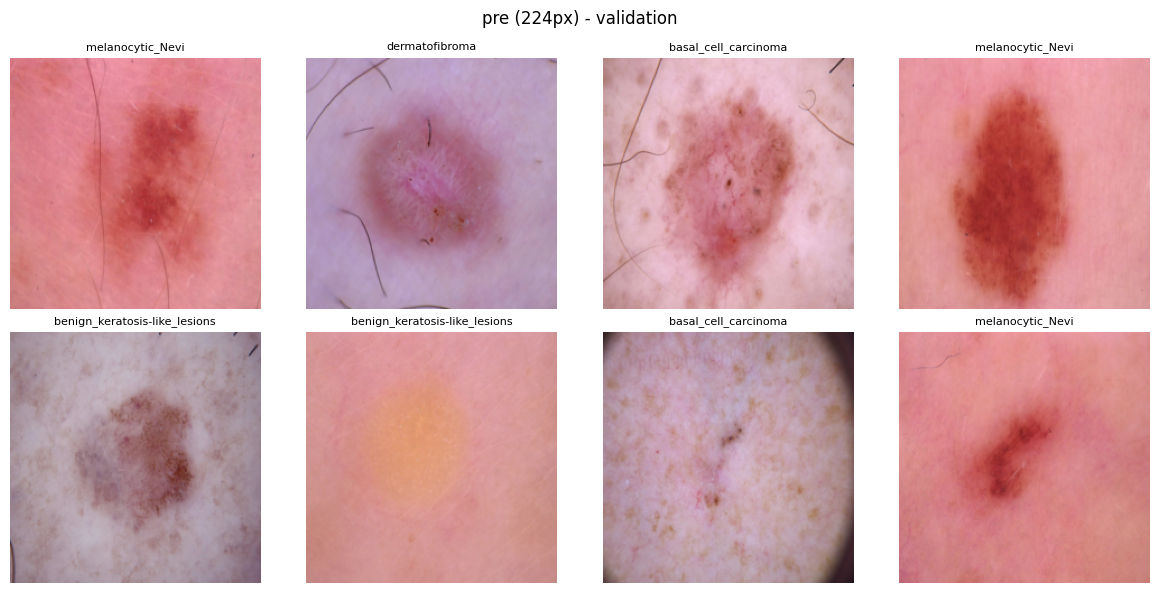

zero  train      (64, 3, 128, 128) torch.float32 [-1.00, 1.00] rótulos [1, 2, 3, 4, 5, 6]


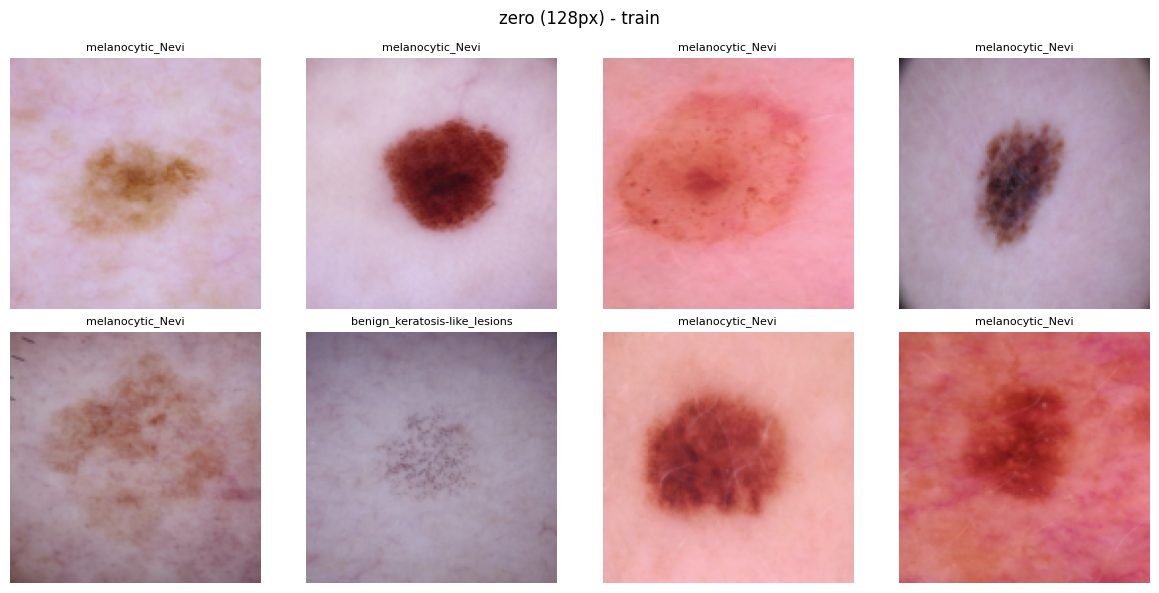

zero  validation (64, 3, 128, 128) torch.float32 [-1.00, 1.00] rótulos [0, 1, 2, 3, 4, 5, 6]


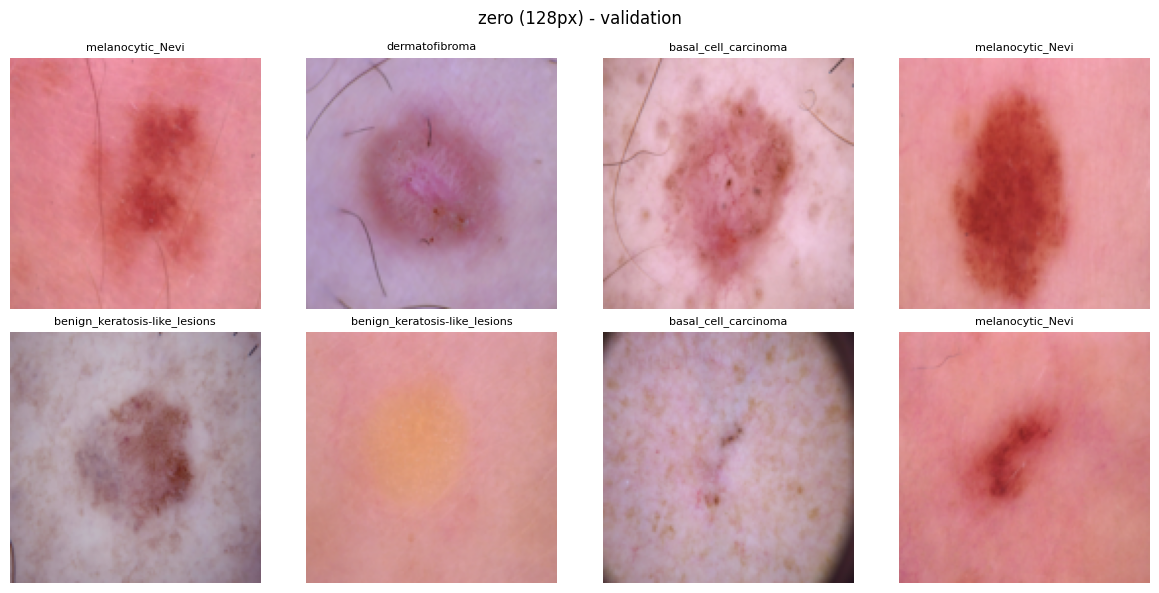

In [10]:
import matplotlib.pyplot as plt

with cronometrar("DataLoaders e teste de 1 batch", TEMPOS):
    # DataLoaders dos dois modelos sobre o mesmo split; só tamanho e batch mudam.
    # Normalização e tamanho do pré-treinado vêm do processor do checkpoint.
    proc = AutoImageProcessor.from_pretrained(CHECKPOINT_PRE)
    # list(...): o processor pode devolver lista ou tupla; lista != tupla em Python
    MEDIA, DESVIO = list(proc.image_mean), list(proc.image_std)
    TAMANHO_PRE = int(proc.size["height"])
    assert (MEDIA, DESVIO, TAMANHO_PRE) == ([0.5] * 3, [0.5] * 3, 224), (
        f"processor diferente do esperado: {MEDIA}, {DESVIO}, {TAMANHO_PRE}"
    )

    configs = {
        "pre":  {"tamanho": TAMANHO_PRE,  "batch_size": BATCH_SIZE["pre"]},
        "zero": {"tamanho": TAMANHO_ZERO, "batch_size": BATCH_SIZE["zero"]},
    }
    loaders = {
        nome: preparar_dataloaders(dataset, SPLIT_OFICIAL, media=MEDIA, desvio=DESVIO, **cfg)
        for nome, cfg in configs.items()
    }

    # Teste de sanidade: 1 batch de treino (com augmentation) e 1 de validação (sem)
    for nome, cfg in configs.items():
        t = cfg["tamanho"]
        assert [len(loaders[nome][s].dataset) for s in ORDEM_SPLITS] == [6999, 1489, 1527]
        for split in ("train", "validation"):
            x, y = next(iter(loaders[nome][split]))
            print(f"{nome:5s} {split:10s} {tuple(x.shape)} {x.dtype} [{x.min():.2f}, {x.max():.2f}] rótulos {sorted(y.unique().tolist())}")
            assert x.shape[1:] == (3, t, t) and x.dtype == torch.float32
            assert -1.0 <= x.min() and x.max() <= 1.0, "normalização fora de [-1, 1]"
            # Sem o Normalize os valores ficariam em [0, 1]: só com ele aparecem negativos
            assert x.min() < 0, "nenhum valor negativo: o Normalize não foi aplicado?"
            assert y.dtype == torch.int64 and 0 <= y.min() and y.max() <= 6

            fig = figura_batch(x, y, INDICE_PARA_CLASSE, MEDIA, DESVIO, f"{nome} ({t}px) - {split}")
            fig.savefig(DIR_REPORT_ASSETS / f"batch_{nome}_{split}.png", dpi=120, bbox_inches="tight")
            display(fig)
            plt.close(fig)

In [11]:
# Versões do runtime do Colab: copie a saída para A1_vision_transformers/requirements.txt (R7)
import importlib.metadata as md
pacotes = ["torch", "torchvision", "transformers", "datasets", "polars", "pandas",
           "pyarrow", "scikit-learn", "pillow", "matplotlib"]
print("\n".join(f"{p}=={md.version(p)}" for p in pacotes))

torch==2.11.0+cu128
torchvision==0.26.0+cu128
transformers==5.16.1
datasets==4.8.5
polars==1.35.2
pandas==2.2.3
pyarrow==23.0.1
scikit-learn==1.6.1
pillow==11.3.0
matplotlib==3.10.0


In [ ]:
# Resumo de tempo e memória por etapa (R8, R9): copie os totais para a célula do topo
tempos = tabela_tempos(TEMPOS)
display(tempos)
tempos.write_csv(DIR_REPORT_ASSETS / "tempos_execucao.csv")

total_parede = time.perf_counter() - _T_INICIO_NOTEBOOK
print(f"Tempo total desde a primeira célula (inclui pausas entre células): {total_parede / 60:.1f} min")

In [12]:
# Copia os artefatos do relatório (tabelas CSV e figuras PNG) para fora do disco temporário.
# /content é apagado quando o runtime é desconectado; rode esta célula ao fim de cada sessão.
import shutil
from datetime import datetime

arquivos = sorted(p.name for p in DIR_REPORT_ASSETS.iterdir() if p.is_file())
print(f"{len(arquivos)} arquivos em {DIR_REPORT_ASSETS}:")
for nome in arquivos:
    print(f"  {nome}")

# 1) Um .zip com tudo (nome com data/hora para não sobrescrever versões anteriores)
carimbo = datetime.now().strftime("%Y%m%d_%H%M")
zip_path = Path(shutil.make_archive(f"/content/report_assets_A1_{carimbo}", "zip", DIR_REPORT_ASSETS))
print(f"\nZip criado: {zip_path} ({zip_path.stat().st_size / 1024:.0f} KB)")

# 2) Se o Drive estiver montado, guarda uma cópia lá (persistente)
DIR_DRIVE_BACKUP = Path("/content/drive/MyDrive/deep_learning_visao_computacional/A1_vision_transformers/report_assets_backup")
if Path("/content/drive/MyDrive").exists():
    DIR_DRIVE_BACKUP.mkdir(parents=True, exist_ok=True)
    shutil.copy2(zip_path, DIR_DRIVE_BACKUP / zip_path.name)
    print(f"Cópia salva no Drive: {DIR_DRIVE_BACKUP / zip_path.name}")
else:
    print("Drive não montado: nenhuma cópia no Drive (use SALVAR_NO_DRIVE = True para montar).")

# 3) Download para o computador (funciona na interface web do Colab)
try:
    from google.colab import files
    files.download(str(zip_path))
except Exception as erro:
    print(f"Download automático indisponível neste ambiente ({type(erro).__name__}).")
    print(f"Baixe manualmente pelo painel de arquivos do Colab: {zip_path}")

11 arquivos em /content/drive/MyDrive/deep_learning_visao_computacional/A1_vision_transformers/outputs/report_assets:
  batch_pre_train.png
  batch_pre_validation.png
  batch_zero_train.png
  batch_zero_validation.png
  contagens.csv
  dx_por_split_antes.csv
  dx_por_split_depois.csv
  vazamento_antes_image_id.csv
  vazamento_antes_lesion_id.csv
  vazamento_depois_image_id.csv
  vazamento_depois_lesion_id.csv

Zip criado: /content/report_assets_A1_20260927_2140.zip (3063 KB)
Cópia salva no Drive: /content/drive/MyDrive/deep_learning_visao_computacional/A1_vision_transformers/report_assets_backup/report_assets_A1_20260927_2140.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>